In [1]:
from sklearn.base import BaseEstimator, RegressorMixin
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error, confusion_matrix, make_scorer
import xgboost as xgb
#import lightgbm as lgb
#import catboost as cb
import joblib
import warnings


warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Загрузка датасета
df = pd.read_csv('period_1_train_data.csv')

# Проверка первых строк
display(df.head())

,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29905 entries, 0 to 29904
Data columns (total 83 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   region_name_cat                                          29905 non-null  object 
 1   district_cat                                             29905 non-null  int64  
 2   corpus_cat                                               29905 non-null  int64  
 3   developer_cat                                            29905 non-null  int64  
 4   agreement_date                                           29905 non-null  object 
 5   floor                                                    29905 non-null  float64
 6   square                                                   29905 non-null  float64
 7   rooms_4                                                  29905 non-null  object 
 8   loc

,district_cat,corpus_cat,developer_cat,floor,square,location_logs_count_mean,location_depth,location_logs_count_std,location_flash_mean_mean,location_hds_ratio_mean_mean,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
count,29905.000000,29905.000000,29905.000000,29905.000000,29905.000000,29572.000000,29572.0,29572.000000,29572.000000,29572.000000,...,29572.000000,29572.000000,29572.000000,29572.000000,29572.000000,29905.000000,29905.000000,29905.000000,29905.000000,29905.000000
mean,51.564621,1263.651129,73.761779,9.713125,57.470088,22.378914,13.0,25.017475,0.211902,1.295069,...,-7.875600,-307.290970,-689.842065,0.888430,8.830718,24606.729857,254.002675,19510.513158,77870.095469,43767.466845
std,23.717749,700.273954,29.491876,6.096880,25.523398,2.474799,0.0,12.711157,0.029187,0.073910,...,93.165568,461.766719,462.132973,0.099720,5.584762,10045.795459,109.070862,21911.397338,32650.894231,27287.683879
min,1.000000,3.000000,2.000000,-9.000000,18.660000,13.178136,13.0,6.480796,0.090068,0.835207,...,-999.000000,-999.000000,-999.000000,0.231314,0.000000,15859.265133,2.000000,0.000000,2581.000000,103.000000
25%,41.000000,737.000000,58.000000,5.000000,38.850000,21.521521,13.0,20.392994,0.194393,1.290643,...,0.832622,-999.000000,-999.000000,0.828147,4.000000,18019.041560,181.000000,0.000000,27353.000000,12638.000000
50%,48.000000,1188.000000,77.000000,9.000000,51.510000,22.574287,13.0,22.389158,0.212908,1.316139,...,0.881220,0.837294,-999.000000,0.895532,8.000000,22257.192093,270.000000,8977.000000,97865.000000,27728.000000
75%,71.000000,1881.000000,91.000000,13.000000,69.580000,23.743690,13.0,24.488793,0.230561,1.333026,...,0.921279,1.019665,0.746081,0.952028,12.000000,27639.644836,341.000000,49786.000000,97865.000000,70661.000000
max,100.000000,2428.000000,134.000000,211.000000,427.230000,33.396234,13.0,106.070634,0.307842,1.384783,...,1.165174,1.611869,1.559104,1.263878,25.000000,142207.315609,457.000000,49786.000000,97865.000000,70661.000000



Количество колонок с пропусками: 70


location_logs_count_mean                              333
location_depth                                        333
location_logs_count_std                               333
location_flash_mean_mean                              333
location_hds_ratio_mean_mean                          333
                                                     ... 
location_public_transport_platform_w_mean_distance    333
location_water_w_mean_distance                        333
location_university_w_mean_distance                   333
location_leisure_w_mean_distance                      333
location_pop_shop_cnt                                 333
Length: 70, dtype: int64

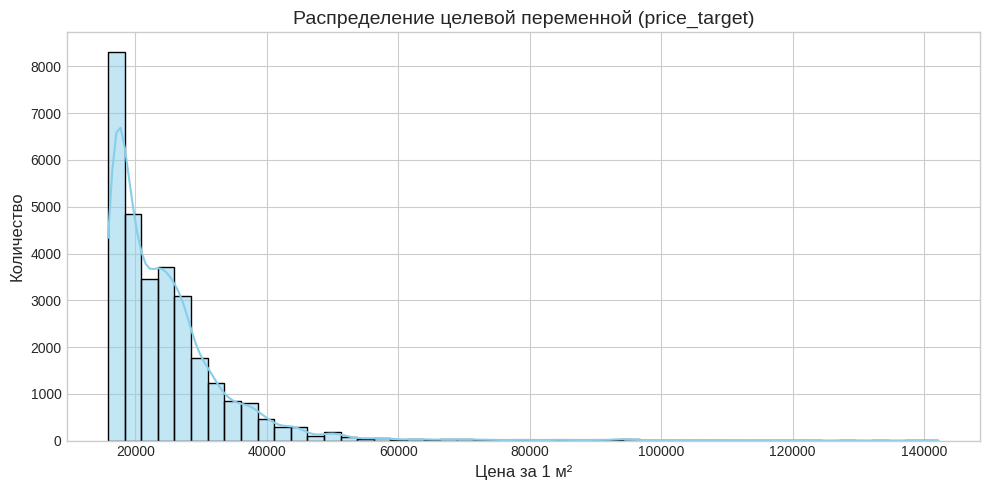

In [3]:
# 1. Типы данных и общая информация
print("Информация о датасете:")
df.info()

# 2. Описательные статистики
print("\nОписательные статистики:")
display(df.describe())

# 3. Проверка пропусков
missing = df.isnull().sum()
missing_cols = missing[missing > 0].sort_values(ascending=False)
print(f"\nКоличество колонок с пропусками: {len(missing_cols)}")
if not missing_cols.empty:
    display(missing_cols)

# 4. Распределение целевой переменной
target_col = 'price_target'
plt.figure(figsize=(10, 5))
sns.histplot(df[target_col], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title('Распределение целевой переменной (price_target)', fontsize=14)
plt.xlabel('Цена за 1 м²', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.tight_layout()
plt.show()


In [4]:
# Разделение на признаки и целевую переменную
if 'id' in df.columns:
    X = df.drop(columns=[target_col, 'id'])
else:
    X = df.drop(columns=[target_col])
y = df[target_col]

# Обработка даты: преобразование в числовые признаки
if 'agreement_date' in X.columns:
    X['agreement_date'] = pd.to_datetime(X['agreement_date'], errors='coerce')
    X['year'] = X['agreement_date'].dt.year
    X['month'] = X['agreement_date'].dt.month
    X['day_of_year'] = X['agreement_date'].dt.dayofyear
    X = X.drop(columns=['agreement_date'])

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Определение типов признаков
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Числовые: импутация медианой + масштабирование (StandardScaler)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Категориальные: импутация модой + OneHotEncoder
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Сборка ColumnTransformer (гарантирует, что масштабирование подгоняется только на train)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ],
    remainder='drop'
)

Train shape: (23924, 84), Test shape: (5981, 84)


In [6]:
""" # Или через Python
import torch
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Модель GPU: {torch.cuda.get_device_name(0)}")
    print(f"Количество GPU: {torch.cuda.device_count()}")

# Альтернативный способ через tensorflow
import tensorflow as tf
print(f"GPU доступны: {tf.config.list_physical_devices('GPU')}") """

' # Или через Python\nimport torch\nprint(f"CUDA доступна: {torch.cuda.is_available()}")\nif torch.cuda.is_available():\n    print(f"Модель GPU: {torch.cuda.get_device_name(0)}")\n    print(f"Количество GPU: {torch.cuda.device_count()}")\n\n# Альтернативный способ через tensorflow\nimport tensorflow as tf\nprint(f"GPU доступны: {tf.config.list_physical_devices(\'GPU\')}") '

In [7]:
# Финальная XGBoost модель (с лучшими параметрами)
xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,          # из ваших параметров
    max_depth=8,
    reg_alpha=1.0,               # из ваших параметров
    subsample=0.9,               # ваш предыдущий лучший параметр
    colsample_bytree=0.7,        # ваш предыдущий лучший параметр
    min_child_weight=3,          # ваш предыдущий лучший параметр
    gamma=1.0,                   # ваш предыдущий лучший параметр
    reg_lambda=1.0,              # ваш предыдущий лучший параметр
    random_state=42,
    device="cuda",
    tree_method='hist',
    verbosity=0
)

# Ridge регрессия (подберем параметры)
ridge_model = Ridge(
    alpha=1.0,           # Сила регуляризации (можно будет оптимизировать)
    random_state=42,
    solver='auto'        # Использует SVD для устойчивости
)

# Стекинг регрессор
stacking_model = StackingRegressor(
    estimators=[
        ('xgboost', xgb_model),
        ('ridge', ridge_model)
    ],
    final_estimator=Ridge(alpha=0.1),  # Мета-обучающийся (можно тоже Ridge)
    cv=3,                         # из ваших параметров
    n_jobs=-1,                    # используем все ядра CPU для ускорения
    verbose=2,                    # показываем прогресс
    passthrough=False             # не передаем исходные признаки в мета-модель
)

# Пайплайн со стекингом
stacking_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('stacking', stacking_model)
])

stacking_pipeline.fit(X_train, y_train)

/home/nik/NoD/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nik/NoD/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nik/NoD/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/nik/NoD/.venv/li

,steps,"[('preprocessor', ...), ('stacking', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
""" # Пространство параметров для стекинга
stacking_params = {
    'stacking__xgboost__n_estimators': [1500, 2000],
    'stacking__xgboost__learning_rate': [0.05, 0.1],
    'stacking__xgboost__max_depth': [7, 8],
    'stacking__xgboost__reg_alpha': [0.5, 1.0],
    'stacking__ridge__alpha': [0.1, 0.5, 1.0, 5.0, 10.0],  # Регуляризация Ridge
    'stacking__final_estimator__alpha': [0.01, 0.1, 0.5, 1.0],  # Мета-обучающийся
    'stacking__cv': [3, 5]  # Для баланса скорость/качество
}

mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

random_search_stacking = RandomizedSearchCV(
    stacking_pipeline,
    param_distributions=stacking_params,
    n_iter=10,              # Меньше итераций из-за тяжелого стекинга
    cv=3,                   # 3-кратная CV для скорости
    scoring=mape_scorer,
    verbose=3,
    random_state=42,
)

random_search_stacking.fit(X_train, y_train)

print(f"🏆 Лучшие параметры стекинга: {random_search_stacking.best_params_}")
print(f"📉 Лучший CV-MAPE: {-random_search_stacking.best_score_:.4f}") """

' # Пространство параметров для стекинга\nstacking_params = {\n    \'stacking__xgboost__n_estimators\': [1500, 2000],\n    \'stacking__xgboost__learning_rate\': [0.05, 0.1],\n    \'stacking__xgboost__max_depth\': [7, 8],\n    \'stacking__xgboost__reg_alpha\': [0.5, 1.0],\n    \'stacking__ridge__alpha\': [0.1, 0.5, 1.0, 5.0, 10.0],  # Регуляризация Ridge\n    \'stacking__final_estimator__alpha\': [0.01, 0.1, 0.5, 1.0],  # Мета-обучающийся\n    \'stacking__cv\': [3, 5]  # Для баланса скорость/качество\n}\n\nmape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)\n\nrandom_search_stacking = RandomizedSearchCV(\n    stacking_pipeline,\n    param_distributions=stacking_params,\n    n_iter=10,              # Меньше итераций из-за тяжелого стекинга\n    cv=3,                   # 3-кратная CV для скорости\n    scoring=mape_scorer,\n    verbose=3,\n    random_state=42,\n)\n\nrandom_search_stacking.fit(X_train, y_train)\n\nprint(f"🏆 Лучшие параметры стекинга: {random_s


Test MAPE: 0.0207 (2.07%)

Матрица ошибок (дискретизированная по квартилям цен):


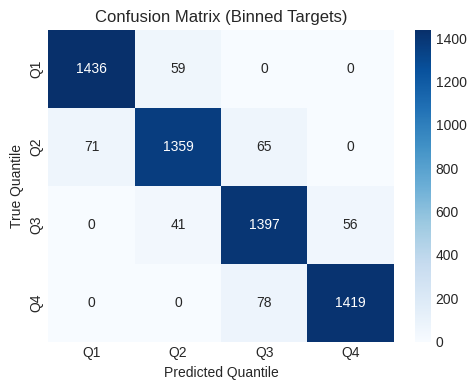

KeyError: 'regressor'

In [12]:
best_model = stacking_pipeline

# 1. Прогноз и MAPE
y_pred = best_model.predict(X_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"\nTest MAPE: {test_mape:.4f} ({test_mape*100:.2f}%)")

# 2. Матрица ошибок (Confusion Matrix)
# Примечание: Confusion Matrix предназначена для классификации. 
# Для регрессионной задачи мы дискретизируем целевую переменную на 5 квартилей.
bins = np.percentile(y_test, [0, 25, 50, 75, 100])
bins[0] -= 1e-5
y_test_bins = np.digitize(y_test, bins[1:-1])
y_pred_bins = np.digitize(y_pred, bins[1:-1])

cm = confusion_matrix(y_test_bins, y_pred_bins)
print("\nМатрица ошибок (дискретизированная по квартилям цен):")

# Визуализация матрицы
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
            yticklabels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.xlabel('Predicted Quantile')
plt.ylabel('True Quantile')
plt.title('Confusion Matrix (Binned Targets)')
plt.tight_layout()
plt.show()

# 3. Важность признаков
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

importances = best_model.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

print("\nТоп-15 важных признаков:")

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.head(15).values, y=feat_imp.head(15).index, palette='viridis')
plt.title('Важность признаков (Feature Importance)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 4. Сохранение лучшей модели
#joblib.dump(best_model, 'best_xgb_regressor.pkl')
#print("💾 Модель успешно сохранена в файл: best_xgb_regressor.pkl")

In [13]:
# Ячейка 7: Генерация submission файла

# 1. Загрузка тестовых данных
df_test = pd.read_csv('test_x.csv')

# 2. Подготовка тестовых данных (те же преобразования, что и при обучении)
# Сохраняем ID если он есть, иначе создаем индекс
if 'id' in df_test.columns:
    test_ids = df_test['id']
    X_test_final = df_test.drop(columns=['id'])
else:
    test_ids = range(len(df_test))
    X_test_final = df_test.copy()

# Обработка даты в тесте (если колонка существует)
if 'agreement_date' in X_test_final.columns:
    X_test_final['agreement_date'] = pd.to_datetime(X_test_final['agreement_date'], errors='coerce')
    X_test_final['year'] = X_test_final['agreement_date'].dt.year
    X_test_final['month'] = X_test_final['agreement_date'].dt.month
    X_test_final['day_of_year'] = X_test_final['agreement_date'].dt.dayofyear
    X_test_final = X_test_final.drop(columns=['agreement_date'])

# 3. Предсказание лучшей моделью
# best_model уже определен в предыдущих ячейках как grid_search.best_estimator_
predictions = best_model.predict(X_test_final)

# 4. Создание DataFrame для отправки
submission_df = pd.DataFrame({
    'id': test_ids,
    'price_target': predictions
})

# 5. Сохранение в CSV
submission_filename = 'submission_2.csv'
submission_df.to_csv(submission_filename, index=False)
print(f"Submission файл успешно сохранен: {submission_filename}")

Submission файл успешно сохранен: submission_2.csv
